# Notebook 8 - Model Validation and Hyperparameter Tuning

This notebook is the validation pass. The earlier comparison notebooks mostly used fixed model settings. Here the goal is more disciplined: keep a held-out test split untouched, use stratified K-fold cross-validation on the training split, select hyperparameters by mean macro F1, and only then check the finalized models on the test set.

This is not a giant grid search. The grids are small on purpose because this is still a class project and MiniLearn has from-scratch code in the loop. MiniLearn Logistic Regression in particular is kept modest because the hand-written optimizer is much slower than sklearn. The point is to show validation logic and final parameter choices without creating a bunch of extra files.

In [1]:
from pathlib import Path
import sys
import time
import warnings

ROOT = Path.cwd()
if not (ROOT / "features" / "features.csv").exists():
    maybe_root = ROOT.parent
    if (maybe_root / "features" / "features.csv").exists():
        ROOT = maybe_root
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier as SkRandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import ParameterGrid
from sklearn.svm import SVC
from xgboost import XGBClassifier

from minilearn.classifiers import DecisionTreeClassifier, KNN, LogisticRegression, RandomForestClassifier
from minilearn.metrics import stratified_k_fold_indices
from minilearn.preprocessing import StandardScaler, train_test_split

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 432
N_SPLITS = 3
FEATURE_PATH = ROOT / "features" / "features.csv"

## Data split

There are two validation layers here:

1. A held-out test split that stays untouched until the end.
2. Stratified K-fold cross-validation inside the training split for tuning.

That separation matters. If hyperparameters are chosen using the test split, the test split stops being an honest final check.

In [2]:
META_COLS = {
    "filename",
    "emotion",
    "emotion_id",
    "actor",
    "gender",
    "vocalchannel",
    "intensity",
    "statement",
    "repetition",
    "duration",
}

df = pd.read_csv(FEATURE_PATH)
feature_cols = [c for c in df.columns if c not in META_COLS]
X = df[feature_cols].to_numpy(dtype=float)
y = df["emotion_id"].to_numpy()

emotion_names = (
    df[["emotion_id", "emotion"]]
    .drop_duplicates()
    .sort_values("emotion_id")
    .set_index("emotion_id")["emotion"]
    .to_dict()
)
labels = sorted(emotion_names)
target_names = [emotion_names[i] for i in labels]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
folds = stratified_k_fold_indices(y_train, n_splits=N_SPLITS, random_state=RANDOM_STATE)

print(f"rows={len(df)}, features={len(feature_cols)}, classes={len(labels)}")
print(f"train={len(X_train)}, test={len(X_test)}, cv_folds={N_SPLITS}")
print(emotion_names)

rows=2452, features=407, classes=8
train=1963, test=489, cv_folds=3
{1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad', 5: 'angry', 6: 'fearful', 7: 'disgust', 8: 'surprised'}


## Fold balance check

The folds are stratified, so each validation fold should carry roughly the same class proportions. This is a quick sanity check before trusting the cross-validation numbers.

In [3]:
balance_rows = []
for fold_i, (_, valid_idx) in enumerate(folds, start=1):
    counts = pd.Series(y_train[valid_idx]).value_counts().sort_index()
    row = {"fold": fold_i, "n_valid": len(valid_idx)}
    for label in labels:
        row[emotion_names[label]] = int(counts.get(label, 0))
    balance_rows.append(row)

fold_balance = pd.DataFrame(balance_rows)
fold_balance

,fold,n_valid,neutral,calm,happy,sad,angry,fearful,disgust,surprised
0,1,659,50,101,101,101,101,101,52,52
1,2,652,50,100,100,100,100,100,51,51
2,3,652,50,100,100,100,100,100,51,51


## Tuning grids

These are finalist models, not every model from the whole project. Macro F1 is the selection metric because every emotion should count, not only the bigger classes.

Scaling is handled inside each fold for models that need it. That avoids leaking validation-fold statistics into the training fold.

In [4]:
def make_xgb(params):
    return XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=2,
        **params,
    )

model_specs = [
    {
        "name": "MiniLearn Logistic Regression",
        "needs_scaling": True,
        "kind": "normal",
        "factory": lambda p: LogisticRegression(**p),
        "grid": list(ParameterGrid({
            "learning_rate": [0.08],
            "reg_strength": [0.001, 0.003],
            "max_iter": [350],
            "tol": [1e-7],
        })),
    },
    {
        "name": "MiniLearn KNN",
        "needs_scaling": True,
        "kind": "normal",
        "factory": lambda p: KNN(**p),
        "grid": list(ParameterGrid({"k": [5, 7], "weights": ["distance"]})),
    },
    {
        "name": "MiniLearn Decision Tree",
        "needs_scaling": False,
        "kind": "normal",
        "factory": lambda p: DecisionTreeClassifier(**p),
        "grid": list(ParameterGrid({"max_depth": [5, 7], "min_samples_leaf": [2]})),
    },
    {
        "name": "MiniLearn Random Forest",
        "needs_scaling": False,
        "kind": "normal",
        "factory": lambda p: RandomForestClassifier(random_state=RANDOM_STATE, **p),
        "grid": list(ParameterGrid({
            "n_estimators": [12, 18],
            "max_depth": [7],
            "min_samples_leaf": [2],
            "max_features": ["sqrt"],
            "max_samples": [0.85],
        })),
    },
    {
        "name": "sklearn RBF SVM",
        "needs_scaling": True,
        "kind": "normal",
        "factory": lambda p: SVC(kernel="rbf", decision_function_shape="ovr", random_state=RANDOM_STATE, **p),
        "grid": list(ParameterGrid({"C": [3, 10, 30], "gamma": ["scale", 0.003]})),
    },
    {
        "name": "sklearn Random Forest",
        "needs_scaling": False,
        "kind": "normal",
        "factory": lambda p: SkRandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **p),
        "grid": list(ParameterGrid({
            "n_estimators": [120, 180],
            "min_samples_leaf": [1, 2],
            "max_features": ["sqrt"],
        })),
    },
    {
        "name": "XGBoost",
        "needs_scaling": False,
        "kind": "xgboost",
        "factory": make_xgb,
        "grid": list(ParameterGrid({
            "n_estimators": [80],
            "max_depth": [3],
            "learning_rate": [0.06, 0.08],
            "subsample": [0.85],
            "colsample_bytree": [0.75],
        })),
    },
]

pd.DataFrame({"model": s["name"], "grid_size": len(s["grid"]), "needs_scaling": s["needs_scaling"]} for s in model_specs)

,model,grid_size,needs_scaling
0,MiniLearn Logistic Regression,2,True
1,MiniLearn KNN,2,True
2,MiniLearn Decision Tree,2,False
3,MiniLearn Random Forest,2,False
4,sklearn RBF SVM,6,True
5,sklearn Random Forest,4,False
6,XGBoost,2,False


## Cross-validation helpers

The tuning loop below is deliberately plain. It makes the split/scaling/training/prediction sequence visible, which is more useful here than hiding everything in a black-box search object.

In [5]:
def fit_predict_fold(spec, params, train_idx, valid_idx):
    X_tr = X_train[train_idx]
    X_val = X_train[valid_idx]
    y_tr = y_train[train_idx]

    if spec["needs_scaling"]:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_val = scaler.transform(X_val)

    model = spec["factory"](params)
    y_fit = y_tr - 1 if spec["kind"] == "xgboost" else y_tr
    model.fit(X_tr, y_fit)
    pred = model.predict(X_val)
    if spec["kind"] == "xgboost":
        pred = pred + 1
    return pred


def tune_model(spec):
    rows = []
    start_model = time.perf_counter()
    for param_i, params in enumerate(spec["grid"], start=1):
        for fold_i, (train_idx, valid_idx) in enumerate(folds, start=1):
            start = time.perf_counter()
            pred = fit_predict_fold(spec, params, train_idx, valid_idx)
            elapsed = time.perf_counter() - start
            rows.append({
                "model": spec["name"],
                "param_i": param_i,
                "fold": fold_i,
                "params": params,
                "accuracy": accuracy_score(y_train[valid_idx], pred),
                "macro_f1": f1_score(y_train[valid_idx], pred, average="macro", zero_division=0),
                "weighted_f1": f1_score(y_train[valid_idx], pred, average="weighted", zero_division=0),
                "seconds": elapsed,
            })
    print(f"{spec['name']} done in {time.perf_counter() - start_model:.1f}s")
    return rows

## Run tuning

This is the slow cell. The search is small, but it still trains several models across folds. The point is that every final hyperparameter choice comes from validation folds instead of eyeballing the held-out test set.

In [6]:
cv_rows = []
for spec in model_specs:
    cv_rows.extend(tune_model(spec))

cv_results = pd.DataFrame(cv_rows)
cv_results.head()

MiniLearn Logistic Regression done in 3.3s


MiniLearn KNN done in 5.7s


MiniLearn Decision Tree done in 11.5s


MiniLearn Random Forest done in 10.9s


sklearn RBF SVM done in 7.0s


sklearn Random Forest done in 7.5s


XGBoost done in 27.9s


,model,param_i,fold,params,accuracy,macro_f1,weighted_f1,seconds
0,MiniLearn Logistic Regression,1,1,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.696510,0.688126,0.691959,0.584518
1,MiniLearn Logistic Regression,1,2,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.702454,0.700009,0.703824,0.484426
2,MiniLearn Logistic Regression,1,3,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.679448,0.665390,0.679420,0.569359
3,MiniLearn Logistic Regression,2,1,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.698027,0.690763,0.693652,0.505826
4,MiniLearn Logistic Regression,2,2,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.700920,0.697695,0.702376,0.596208


## Pick finalized hyperparameters

The selected parameter set is the one with the best mean macro F1. Accuracy is used as a secondary sort key only when macro F1 is basically tied.

In [7]:
summary_rows = []
for (model_name, param_i), group in cv_results.groupby(["model", "param_i"]):
    params = group["params"].iloc[0]
    summary_rows.append({
        "model": model_name,
        "param_i": param_i,
        "params": params,
        "mean_accuracy": group["accuracy"].mean(),
        "std_accuracy": group["accuracy"].std(ddof=0),
        "mean_macro_f1": group["macro_f1"].mean(),
        "std_macro_f1": group["macro_f1"].std(ddof=0),
        "mean_weighted_f1": group["weighted_f1"].mean(),
        "mean_seconds_per_fold": group["seconds"].mean(),
    })

cv_summary = pd.DataFrame(summary_rows)
cv_summary = cv_summary.sort_values(["model", "mean_macro_f1", "mean_accuracy"], ascending=[True, False, False])

best_by_model = (
    cv_summary
    .sort_values(["model", "mean_macro_f1", "mean_accuracy"], ascending=[True, False, False])
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("mean_macro_f1", ascending=False)
    .reset_index(drop=True)
)

show = best_by_model.copy()
for col in ["mean_accuracy", "std_accuracy", "mean_macro_f1", "std_macro_f1", "mean_weighted_f1", "mean_seconds_per_fold"]:
    show[col] = show[col].round(4)
show

,model,param_i,params,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_weighted_f1,mean_seconds_per_fold
0,sklearn RBF SVM,3,"{'C': 10, 'gamma': 'scale'}",0.7799,0.0182,0.7743,0.0183,0.7791,0.3811
1,MiniLearn Logistic Regression,1,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.6928,0.0098,0.6845,0.0144,0.6917,0.5461
2,sklearn Random Forest,2,"{'max_features': 'sqrt', 'min_samples_leaf': 1...",0.6566,0.0148,0.6474,0.0171,0.6530,0.7145
3,XGBoost,2,"{'colsample_bytree': 0.75, 'learning_rate': 0....",0.6577,0.0123,0.6458,0.0128,0.6557,4.7690
4,MiniLearn KNN,1,"{'k': 5, 'weights': 'distance'}",0.5955,0.0094,0.5850,0.0113,0.5892,0.9482
5,MiniLearn Random Forest,2,"{'max_depth': 7, 'max_features': 'sqrt', 'max_...",0.4646,0.0110,0.4313,0.0179,0.4510,2.1850
6,MiniLearn Decision Tree,2,"{'max_depth': 7, 'min_samples_leaf': 2}",0.4244,0.0166,0.4091,0.0131,0.4216,2.5080


In [8]:
all_tuning_results = cv_summary.copy()
for col in ["mean_accuracy", "std_accuracy", "mean_macro_f1", "std_macro_f1", "mean_weighted_f1", "mean_seconds_per_fold"]:
    all_tuning_results[col] = all_tuning_results[col].round(4)
all_tuning_results.sort_values(["model", "mean_macro_f1"], ascending=[True, False])

,model,param_i,params,mean_accuracy,std_accuracy,mean_macro_f1,std_macro_f1,mean_weighted_f1,mean_seconds_per_fold
1,MiniLearn Decision Tree,2,"{'max_depth': 7, 'min_samples_leaf': 2}",0.4244,0.0166,0.4091,0.0131,0.4216,2.5080
0,MiniLearn Decision Tree,1,"{'max_depth': 5, 'min_samples_leaf': 2}",0.3914,0.0348,0.3627,0.0387,0.3796,1.3044
2,MiniLearn KNN,1,"{'k': 5, 'weights': 'distance'}",0.5955,0.0094,0.5850,0.0113,0.5892,0.9482
3,MiniLearn KNN,2,"{'k': 7, 'weights': 'distance'}",0.5822,0.0064,0.5640,0.0060,0.5749,0.9353
4,MiniLearn Logistic Regression,1,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.6928,0.0098,0.6845,0.0144,0.6917,0.5461
5,MiniLearn Logistic Regression,2,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.6923,0.0102,0.6842,0.0145,0.6913,0.5443
7,MiniLearn Random Forest,2,"{'max_depth': 7, 'max_features': 'sqrt', 'max_...",0.4646,0.0110,0.4313,0.0179,0.4510,2.1850
6,MiniLearn Random Forest,1,"{'max_depth': 7, 'max_features': 'sqrt', 'max_...",0.4432,0.0044,0.4147,0.0140,0.4317,1.4315
9,XGBoost,2,"{'colsample_bytree': 0.75, 'learning_rate': 0....",0.6577,0.0123,0.6458,0.0128,0.6557,4.7690
8,XGBoost,1,"{'colsample_bytree': 0.75, 'learning_rate': 0....",0.6358,0.0049,0.6213,0.0080,0.6332,4.5266


## Validation score plot

This plot is validation-only. It should be read as: based on training-fold cross-validation, these are the finalist settings I would carry into a final held-out test check.

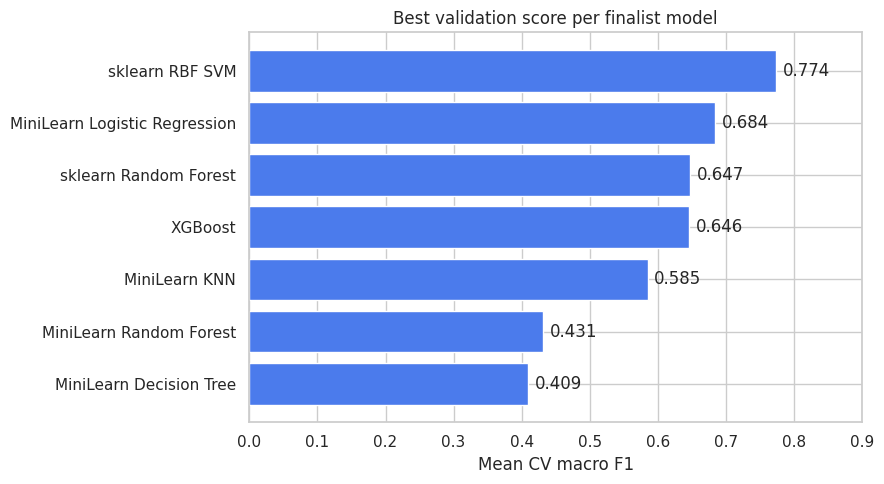

In [9]:
plot_df = show.sort_values("mean_macro_f1", ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df["model"], plot_df["mean_macro_f1"], color="#4b7bec")
ax.set_xlabel("Mean CV macro F1")
ax.set_title("Best validation score per finalist model")
ax.set_xlim(0, max(0.9, plot_df["mean_macro_f1"].max() + 0.08))
for i, value in enumerate(plot_df["mean_macro_f1"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")
plt.tight_layout()
plt.show()

## Final held-out test check

Now the selected hyperparameters get trained on the full training split and evaluated once on the held-out test split. This is the number I would use as the validation-aware final comparison, not the fold mean.

In [10]:
def train_final_and_score(spec, params):
    X_tr = X_train
    X_te = X_test
    if spec["needs_scaling"]:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

    model = spec["factory"](params)
    y_fit = y_train - 1 if spec["kind"] == "xgboost" else y_train
    start = time.perf_counter()
    model.fit(X_tr, y_fit)
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    pred = model.predict(X_te)
    predict_seconds = time.perf_counter() - start
    if spec["kind"] == "xgboost":
        pred = pred + 1
    return model, pred, fit_seconds, predict_seconds

spec_lookup = {spec["name"]: spec for spec in model_specs}
final_rows = []
final_models = {}
final_predictions = {}
for row in best_by_model.itertuples(index=False):
    spec = spec_lookup[row.model]
    model, pred, fit_seconds, predict_seconds = train_final_and_score(spec, row.params)
    final_models[row.model] = model
    final_predictions[row.model] = pred
    final_rows.append({
        "model": row.model,
        "selected_params": row.params,
        "cv_macro_f1": row.mean_macro_f1,
        "test_accuracy": accuracy_score(y_test, pred),
        "test_macro_f1": f1_score(y_test, pred, average="macro", zero_division=0),
        "test_weighted_f1": f1_score(y_test, pred, average="weighted", zero_division=0),
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
    })

final_results = pd.DataFrame(final_rows).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
final_show = final_results.copy()
for col in ["cv_macro_f1", "test_accuracy", "test_macro_f1", "test_weighted_f1", "fit_seconds", "predict_seconds"]:
    final_show[col] = final_show[col].round(4)
final_show

,model,selected_params,cv_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,fit_seconds,predict_seconds
0,sklearn RBF SVM,"{'C': 10, 'gamma': 'scale'}",0.7743,0.8037,0.7928,0.8024,0.4453,0.1873
1,MiniLearn Logistic Regression,"{'learning_rate': 0.08, 'max_iter': 350, 'reg_...",0.6845,0.6851,0.6787,0.6842,0.7040,0.0005
2,XGBoost,"{'colsample_bytree': 0.75, 'learning_rate': 0....",0.6458,0.6708,0.6613,0.6684,5.0481,0.0024
3,MiniLearn KNN,"{'k': 5, 'weights': 'distance'}",0.5850,0.6728,0.6503,0.6720,0.0001,1.2115
4,sklearn Random Forest,"{'max_features': 'sqrt', 'min_samples_leaf': 1...",0.6474,0.6667,0.6456,0.6644,0.9365,0.0771
5,MiniLearn Decision Tree,"{'max_depth': 7, 'min_samples_leaf': 2}",0.4091,0.4458,0.4364,0.4420,3.3210,0.0010
6,MiniLearn Random Forest,"{'max_depth': 7, 'max_features': 'sqrt', 'max_...",0.4313,0.4519,0.4242,0.4464,2.6527,0.0160


## Best tuned model report

This report is the last sanity check: after tuning, which emotions are still hard? A strong final metric is less useful if it hides one emotion getting ignored.

In [11]:
best_name = final_results.iloc[0]["model"]
best_pred = final_predictions[best_name]
print("Best tuned held-out model:", best_name)
print("Selected params:", final_results.iloc[0]["selected_params"])
print(classification_report(y_test, best_pred, labels=labels, target_names=target_names, zero_division=0))

Best tuned held-out model: sklearn RBF SVM
Selected params: {'C': 10, 'gamma': 'scale'}
              precision    recall  f1-score   support

     neutral       0.75      0.79      0.77        38
        calm       0.89      0.96      0.92        75
       happy       0.79      0.81      0.80        75
         sad       0.74      0.73      0.74        75
       angry       0.86      0.85      0.86        75
     fearful       0.76      0.77      0.77        75
     disgust       0.72      0.76      0.74        38
   surprised       0.89      0.63      0.74        38

    accuracy                           0.80       489
   macro avg       0.80      0.79      0.79       489
weighted avg       0.81      0.80      0.80       489



## Notes for the report

- Stratified K-fold keeps each validation fold close to the full class distribution.
- Macro F1 is the selection metric because every emotion class matters.
- Scaling stays inside each fold for the models that need it, which prevents validation leakage.
- The final test score can be lower or higher than the CV score because it is one held-out split instead of an average across folds.
- These selected hyperparameters are now the project's validation-backed choices, but they are still modest grids, not a claim of global optimality.